In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'  # <-- Keep text as real text

import geopandas as gpd
import rasterio
import numpy as np
import os
import glob
import datetime
from matplotlib import font_manager
# Find the path to the Arial font
arial_font_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'  # Update this path based on your system

# Add the Arial font to the font manager
font_manager.fontManager.addfont(arial_font_path)

# Set the font to Arial
plt.rcParams['font.family'] = 'Arial'


In [10]:
crop_df = pd.read_csv('/home/rene1337/RSCPH/significant_rel_diff_ls789_m2_significant_relative_diff_silver_sweep_9_crop_2000.csv')
shrub_df = pd.read_csv('/home/rene1337/RSCPH/significant_rel_diff_ls789_m2_significant_relative_diff_silver_sweep_9_shrub_2020.csv')
# join the dataframes based on tile_id
df = pd.merge(crop_df, shrub_df, on='tile_id')
df = df.drop(columns=['geometry_x', 'country_y', 'region_y', 'geometry_y'])
print(len(df))
# where row = GMB rename to Gambia 

country_rename = [("GMB", "Gambia"), ("TGO", "Togo"), ("BFA", "Burkina Faso"),
 ("BEN", "Benin"), ("GIN", "Guinea"), ("GHA", "Ghana"),
 ("MLI", "Mali"), ("NER", "Niger"), ("NGA", "Nigeria"),
 ("SEN", "Senegal"), ("TCD", "Chad"), ("CIV", "Côte d'Ivoire"),
 ("ETH", "Ethiopia"), ("ERI", "Eritrea"), ("SDN", "Sudan"),
 ("CMR", "Cameroon"), ("CAF", "Central African Republic"), ("SSD", "South Sudan"), ("MRT", "Mauritania")]

for i, j in country_rename:
    df.loc[df['country_x'] == i, 'country_x'] = j
df = df[df['country_x'] != 'Central African Republic']
df = df[df['country_x'] != 'Togo']
df = df[df['country_x'] != 'Ghana']
df = df[df['country_x'] != 'Benin']
#df = df[df['country_x'] != 'Gambia']

2284


In [11]:
df

,tile_id,country_x,region_x,precip_x,mean_pos_sig_diff_x,mean_neg_sig_diff_x,mean_net_sig_diff_x,pos_diff_m2_x,neg_diff_m2_x,pos_pixels_x,...,total_pixels_x,precip_y,mean_pos_sig_diff_y,mean_neg_sig_diff_y,mean_net_sig_diff_y,pos_diff_m2_y,neg_diff_m2_y,pos_pixels_y,neg_pixels_y,total_pixels_y
0,-4_11_4,Burkina Faso,Sud-Ouest,800,1.378071,0.054128,NaN,6810054.0,267488.220,31422,...,4941729,800,8.610428,1.141918,NaN,4.255040e+07,5.643052e+06,196892,89051,4941729
1,-4_11_7,Burkina Faso,Sud-Ouest,800,3.694496,0.080008,NaN,18257200.0,395378.500,82203,...,4941729,800,11.251610,1.739102,NaN,5.560241e+07,8.594171e+06,268387,144590,4941729
2,-4_11_2,Burkina Faso,Sud-Ouest,800,0.322693,0.005249,NaN,1595381.0,25950.943,6700,...,4943952,800,26.110771,0.246441,NaN,1.290904e+08,1.218390e+06,518005,19224,4943952
3,-4_11_5,Burkina Faso,Sud-Ouest,800,0.187783,0.013648,NaN,928389.2,67472.750,3125,...,4943952,800,14.346628,2.594536,NaN,7.092904e+07,1.282726e+07,319908,236914,4943952
4,-4_11_8,Burkina Faso,Sud-Ouest,800,0.610400,0.020803,NaN,3017786.2,102846.660,11640,...,4943952,800,19.359413,2.131380,NaN,9.571201e+07,1.053744e+07,447906,195877,4943952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2279,25_18_0,Chad,Ennedi Est,150,0.000000,0.000000,0.0,0.0,0.000,0,...,4943952,150,3.099220,0.035171,NaN,1.532240e+07,1.738842e+05,45772,2561,4943952
2280,25_18_1,Chad,Ennedi Est,150,0.000000,0.000000,0.0,0.0,0.000,0,...,4946176,150,0.381010,0.003099,NaN,1.884542e+06,1.533011e+04,7468,216,4946176
2281,25_18_2,Chad,Ennedi Est,150,0.000000,0.000000,0.0,0.0,0.000,0,...,4943952,150,0.015673,0.000908,NaN,7.748535e+04,4.488208e+03,107,77,4943952
2282,26_18_0,Chad,Ennedi Est,150,0.000000,0.000000,0.0,0.0,0.000,0,...,4943952,150,0.000000,0.000000,0.0,0.000000e+00,0.000000e+00,0,0,4943952


In [21]:

df_no_id = df.drop(columns=['tile_id'])
df = df_no_id.copy()

In [22]:
# only rows where precip is greater than 300 mm
df_300 = df[df['precip_x'] >= 300]
df_300.columns

Index(['country_x', 'region_x', 'precip_x', 'mean_pos_sig_diff_x',
       'mean_neg_sig_diff_x', 'mean_net_sig_diff_x', 'pos_diff_m2_x',
       'neg_diff_m2_x', 'pos_pixels_x', 'neg_pixels_x', 'total_pixels_x',
       'precip_y', 'mean_pos_sig_diff_y', 'mean_neg_sig_diff_y',
       'mean_net_sig_diff_y', 'pos_diff_m2_y', 'neg_diff_m2_y', 'pos_pixels_y',
       'neg_pixels_y', 'total_pixels_y', 'relative_gain_abs',
       'relative_loss_abs', 'net_change_cropland', 'net_change_shrubland'],
      dtype='object')

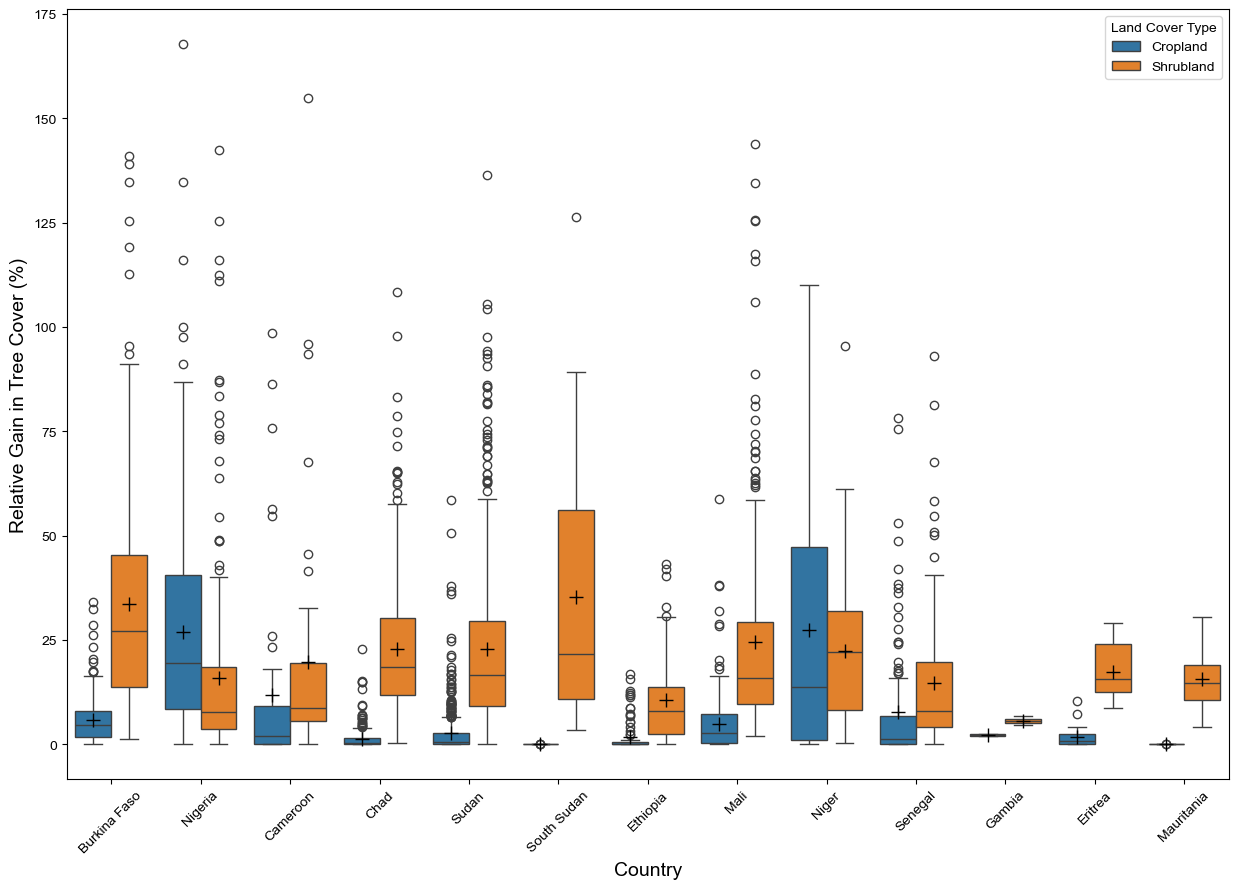

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Melt the DataFrame to long format
df_melted = df_300.melt(id_vars=['country_x'], value_vars=['mean_pos_sig_diff_x', 'mean_pos_sig_diff_y'], 
                        var_name='Type', value_name='Mean Positive Significant Difference')

# Create the box plot
fig, ax = plt.subplots(figsize=(15, 10))
# plot mean on box plot
sns.boxplot(x='country_x', y='Mean Positive Significant Difference', hue='Type', data=df_melted, ax=ax, showmeans=True, meanprops={'marker':'+', 'markeredgecolor':'black', 'markersize':'10'}) 
#sns.boxplot(x='country_x', y='Mean Positive Significant Difference', hue='Type', data=df_melted, ax=ax, legend=True)

# change legend text
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[0:], labels=['Cropland', 'Shrubland'], title='Land Cover Type')

# Add labels and rotate x-axis labels
plt.xlabel('Country', fontsize=14)
plt.ylabel('Relative Gain in Tree Cover (%)', fontsize=14)

plt.xticks(rotation=45)

# Show the plot
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/methods/boxplot_pos_sig_diff_300.svg', bbox_inches='tight')

In [24]:
df["relative_gain_abs"] = (df["mean_pos_sig_diff_x"] - df["mean_pos_sig_diff_y"])
df["relative_loss_abs"] = (df["mean_neg_sig_diff_x"] - df["mean_neg_sig_diff_y"])
df["net_change_cropland"] = (df["mean_pos_sig_diff_x"] - df["mean_neg_sig_diff_x"])
df["net_change_shrubland"] = (df["mean_pos_sig_diff_y"] - df["mean_neg_sig_diff_y"])
# group df by region but retain the country
df_region_mean = df.groupby(['region_x', 'country_x']).mean()
df_region_mean['region'] = df_region_mean.index.get_level_values(0)
df_region_mean['country'] = df_region_mean.index.get_level_values(1)

df_niger = df_region_mean[df_region_mean['country'] == 'Niger']
print(len(df_niger.index))
df_country_mean = df.groupby(['country_x']).mean(numeric_only=True)
df_country_sum = df.groupby(['country_x']).sum(numeric_only=True)

df_country_mean_300 = df_300.groupby(['country_x']).mean(numeric_only=True)
df_country_sum_300 = df_300.groupby(['country_x']).sum(numeric_only=True)


df_precip = df.groupby(['precip_x', 'country_x']).mean(numeric_only=True)
df_country_mean["relative_gain_country"] = (df_country_mean["mean_pos_sig_diff_x"] - df_country_mean["mean_pos_sig_diff_y"]) / df_country_mean["mean_pos_sig_diff_y"] * 100
df_country_mean_300["relative_gain_country"] = (df_country_mean_300["mean_pos_sig_diff_x"] - df_country_mean_300["mean_pos_sig_diff_y"]) / df_country_mean_300["mean_pos_sig_diff_y"] * 100
df_region_mean["relative_gain_region"] = (df_region_mean["mean_pos_sig_diff_x"] - df_region_mean["mean_pos_sig_diff_y"]) / df_region_mean["mean_pos_sig_diff_y"] * 100
df_country_mean_300["relative_change"] = (df_country_mean["net_change_cropland"] - df_country_mean["net_change_shrubland"]) / df_country_mean["net_change_shrubland"] * 100
df_niger["relative_gain_region"] = (df_niger["mean_pos_sig_diff_x"] - df_niger["mean_pos_sig_diff_y"]) / df_niger["mean_pos_sig_diff_y"] * 100

7


/tmp/ipykernel_2606806/2931437351.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_niger["relative_gain_region"] = (df_niger["mean_pos_sig_diff_x"] - df_niger["mean_pos_sig_diff_y"]) / df_niger["mean_pos_sig_diff_y"] * 100


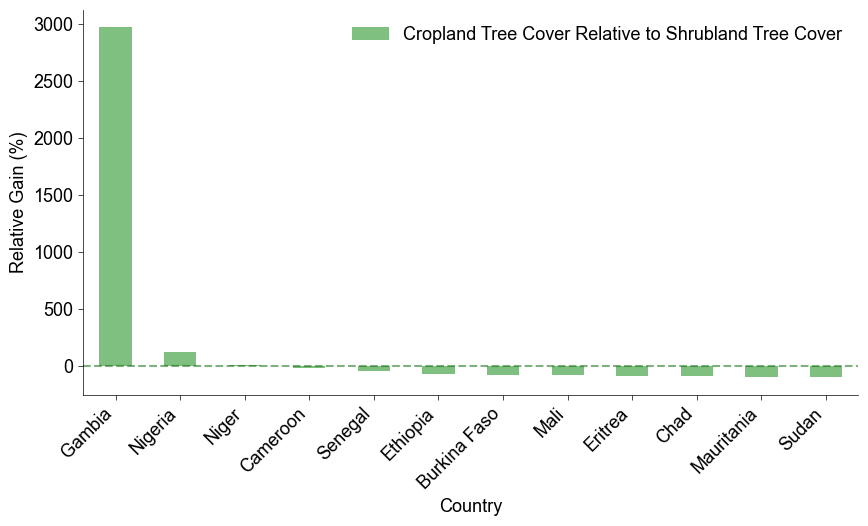

In [68]:
df_country_mean_300.sort_values(by="relative_change", ascending=False, inplace=True)

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
#df_country_sum.sort_values(by='net_diff_hct', ascending=True, inplace=True)
df_country_mean_300.plot(kind='bar', y=['relative_change'], ax=ax, alpha=0.5, color=['green'], legend=False)
# remove borders
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

# 0 line
plt.legend(['Cropland Tree Cover Relative to Shrubland Tree Cover'], edgecolor='none', fontsize=13)

plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)
#set font ot arial
#set font ot arial
plt.rcParams['font.family'] = 'Arial'

plt.ylabel('Relative Gain (%)', fontsize=13)
plt.xlabel('Country', fontsize=13)

plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/methods/relative_change_sahel.svg', bbox_inches='tight')

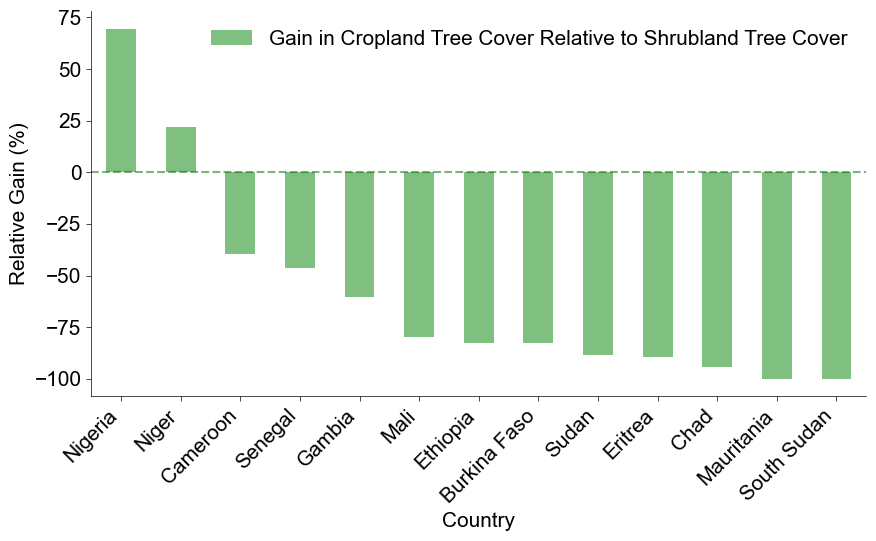

In [26]:


df_country_mean_300.sort_values(by="relative_gain_country", ascending=False, inplace=True)

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
#df_country_sum.sort_values(by='net_diff_hct', ascending=True, inplace=True)
df_country_mean_300.plot(kind='bar', y=['relative_gain_country'], ax=ax, alpha=0.5, color=['green'], legend=False)
# remove borders
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

# 0 line
plt.legend(['Gain in Cropland Tree Cover Relative to Shrubland Tree Cover'], edgecolor='none', fontsize=15)

plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)
#set font ot arial
#set font ot arial
plt.rcParams['font.family'] = 'Arial'

plt.ylabel('Relative Gain (%)', fontsize=15)
plt.xlabel('Country', fontsize=15)

plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/methods/relative_gain_sahel.svg', bbox_inches='tight')

Text(0.5, 0, 'Country')

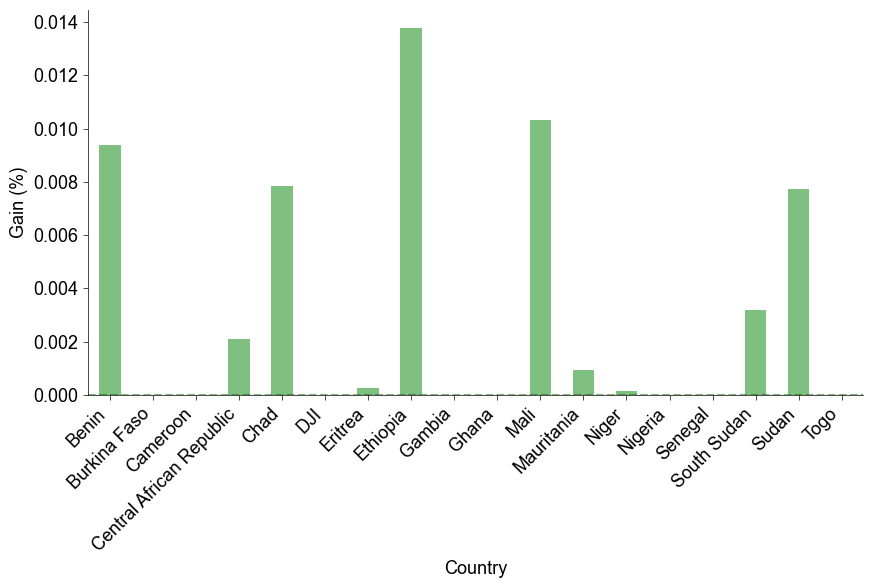

In [ ]:
df_country_mean_300 = df_300.groupby(['country_x']).mean()
df_country_sum_300 = df_300.groupby(['country_x']).sum()

df_region_mean.sort_values(by="country_x", ascending=False, inplace=True)

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
#df_country_sum.sort_values(by='net_diff_hct', ascending=True, inplace=True)
df_country_mean.plot(kind='bar', y=['mean_net_sig_diff_x'], ax=ax, alpha=0.5, color=['green'], legend=False)
# plot on two axes
# remove borders
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

# 0 line

plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)
#set font ot arial
#set font ot arial
plt.rcParams['font.family'] = 'Arial'

plt.ylabel('Gain (%)', fontsize=13)
plt.xlabel('Country', fontsize=13)


Text(0.5, 0, 'Country')

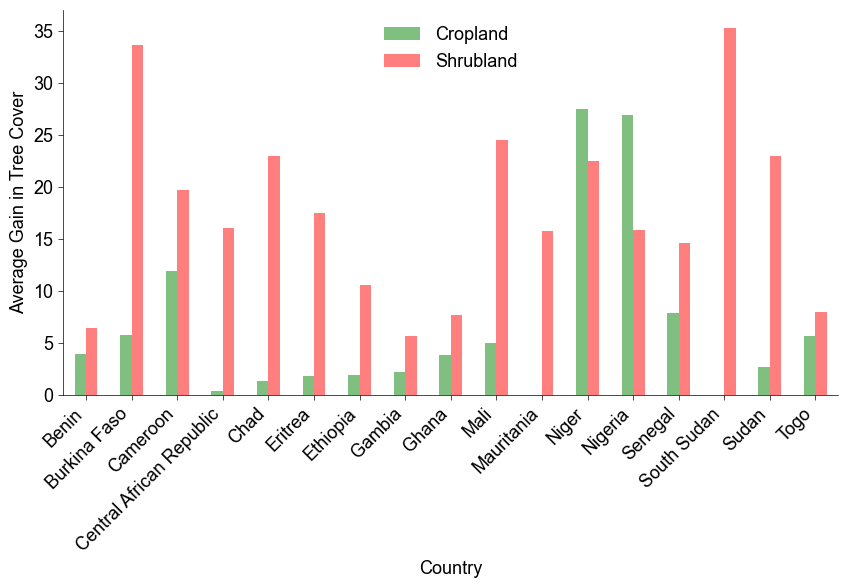

In [61]:
df_region_mean.sort_values(by="country_x", ascending=False, inplace=True)

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
#df_country_sum.sort_values(by='net_diff_hct', ascending=True, inplace=True)
df_country_mean_300.plot(kind='bar', y=['mean_pos_sig_diff_x', 'mean_pos_sig_diff_y'], ax=ax, alpha=0.5, color=['green', 'red'], legend=False)
# remove borders
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

# 0 line
plt.legend(['Cropland', 'Shrubland'], fontsize=13, frameon=False)

#plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)
#set font ot arial
#set font ot arial
plt.rcParams['font.family'] = 'Arial'

plt.ylabel('Average Gain in Tree Cover', fontsize=13)
plt.xlabel('Country', fontsize=13)

In [183]:
df = df_country_sum
df = df[df.index != 'DJI']
df = df[df.index != 'South Sudan']
df = df[df.index != 'Central African Republic']
df = df[df.index != 'Togo']
df = df[df.index != 'Ghana']
df = df[df.index != 'Benin']
df_country_sum = df

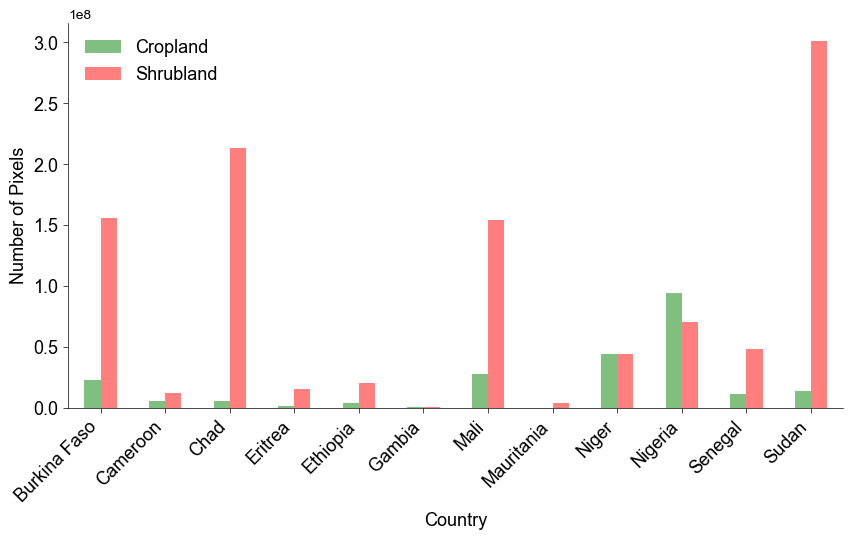

In [33]:
df_region_mean.sort_values(by="country_x", ascending=False, inplace=True)

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
#df_country_sum.sort_values(by='net_diff_hct', ascending=True, inplace=True)
df_country_sum_300.plot(kind='bar', y=['pos_pixels_x', 'pos_pixels_y'], ax=ax, alpha=0.5, color=['green', 'red'], legend=False)
# remove borders
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

# 0 line
plt.legend(['Cropland', 'Shrubland'], fontsize=13, frameon=False)

#plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)
#set font ot arial
#set font ot arial
plt.rcParams['font.family'] = 'Arial'

plt.ylabel('Number of Pixels', fontsize=13)
plt.xlabel('Country', fontsize=13)
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/methods/relative_gain_num_pixels.svg', bbox_inches='tight')


Total area: 2335771.72309 km2


/tmp/ipykernel_172327/937365798.py:19: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_region_sum = df.groupby(['region', 'country']).sum()
/tmp/ipykernel_172327/937365798.py:22: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_country_sum = df.groupby(['country']).sum()


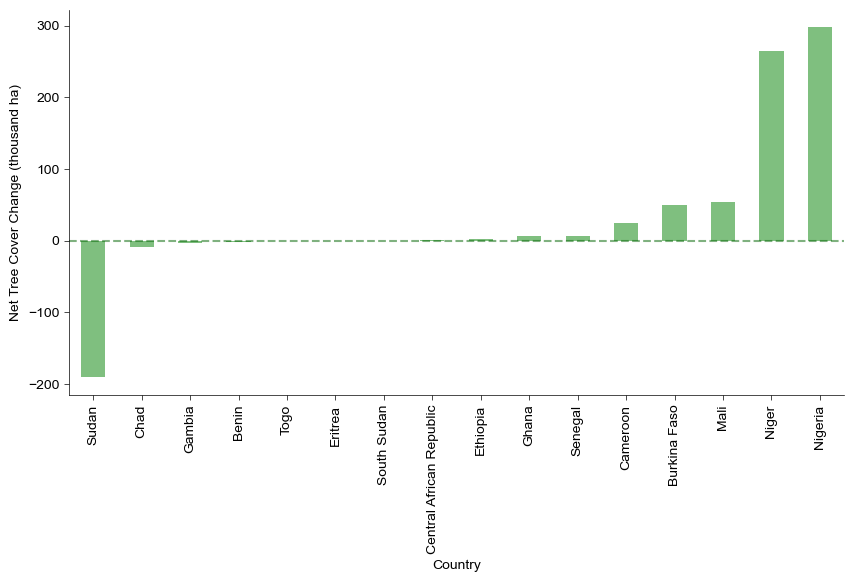

In [7]:
df = ag_2000_df
df['neg_area'] = (df['neg_pixels']*215)/10000000000
df['pos_area'] = (df['pos_pixels']*215)/10000000000
df['total_area'] = (df['total_pixels']*215)/10000
df["pos_diff_km2"] = df['pos_diff_m2'] / 100
df["neg_diff_km2"] = df['neg_diff_m2'] / 100
df["pos_diff_hct"] = df['pos_diff_m2'] / 1000
df["neg_diff_hct"] = df['neg_diff_m2'] / 1000
df["net_diff_hct"] = df["pos_diff_hct"] - df["neg_diff_hct"]
df_dropped = df.drop(columns=['geometry', 'tile_id', 'country', 'region'])
df_sum = df_dropped.sum()
total_area = (df_sum['total_pixels']*215)/1000000
print(f'Total area: {total_area} km2')
df["total_area"] = total_area
df["percent_positive"] = (df["pos_area"]/df["total_area"])*100
df["percent_negative"] = (df["neg_area"]/df["total_area"])*100

# group df by region but retain the country
df_region_sum = df.groupby(['region', 'country']).sum()
df_region_count = df.groupby(['region', 'country']).count()

df_country_sum = df.groupby(['country']).sum()
df_country_count = df.groupby(['country']).count()

# remove rows where country == mrt
df_country_sum = df_country_sum[df_country_sum.index != 'MRT']
df_country_sum = df_country_sum[df_country_sum.index != 'DJI']
df_country_sum = df_country_sum[df_country_sum.index != 'SSD']
df_country_sum = df_country_sum[df_country_sum.index != 'CAF']

df_region = df_region_sum #.div(total_area)
df_country = df_country_sum #.div(total_area)

df_region.sort_values(by="country", ascending=False, inplace=True)
#df_region.reset_index(inplace=True)
df_region["country"] = df_region.index.get_level_values(1)
df_region["region"] = df_region.index.get_level_values(0)
#df_region.reset_index(inplace=True)
df_region.set_index('region', inplace=True)

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
df_country.sort_values(by='net_diff_hct', ascending=True, inplace=True)
df_country.plot(kind='bar', y='net_diff_hct', ax=ax, alpha=0.5, color=['green'], legend=False)
# remove borders
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)

#set font ot arial
plt.rcParams['font.family'] = 'Dejavu Sans'

# 0 line
plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)

plt.ylabel('Net Tree Cover Change (thousand ha)')
plt.xlabel('Country')
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_ls789_net_hct_ps.png', dpi=1000, bbox_inches='tight')
plt.show()
ag_2000_df = df


In [6]:
pos_diff_km2 = df_sum['pos_diff_m2'] / 100
neg_diff_km2 = df_sum['neg_diff_m2'] / 100
df_sum["pos_diff_km2"] = pos_diff_km2
df_sum["neg_diff_km2"] = neg_diff_km2
print(f'Positive change in tree cover: {pos_diff_km2} km2')
print(f'Negative change in tree cover: {neg_diff_km2} km2')

pos_area = (df_sum['pos_pixels']*215)/1000000
neg_area = (df_sum['neg_pixels']*215)/1000000
print(f'Positive area: {pos_area} km2')
print(f'Negative area: {neg_area} km2')

total_area = (df_sum['total_pixels']*215)/1000000
print(f'Total area: {total_area} km2')

pos_percent_of_sahel = pos_area/total_area * 100
neg_percent_of_sahel = neg_area/total_area * 100
print(f'Positive area as % of Sahel: {pos_percent_of_sahel}')
print(f'Negative area as % of Sahel: {neg_percent_of_sahel}')

print(f'Positive change in tree cover as % of Sahel: {df_sum["pos_diff_km2"]/3053200 * 100}')

Positive change in tree cover: 13350.174634532998 km2
Negative change in tree cover: 8353.759365503734 km2
Positive area: 92245.76204 km2
Negative area: 75073.310205 km2
Total area: 2335771.72309 km2
Positive area as % of Sahel: 3.949262726666105
Negative area as % of Sahel: 3.214068800596887
Positive change in tree cover as % of Sahel: 0.43725188767630674


/tmp/ipykernel_219399/210218472.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_region_sum = df.groupby(['region', 'country']).sum()
/tmp/ipykernel_219399/210218472.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_country_sum = df.groupby(['country']).sum()


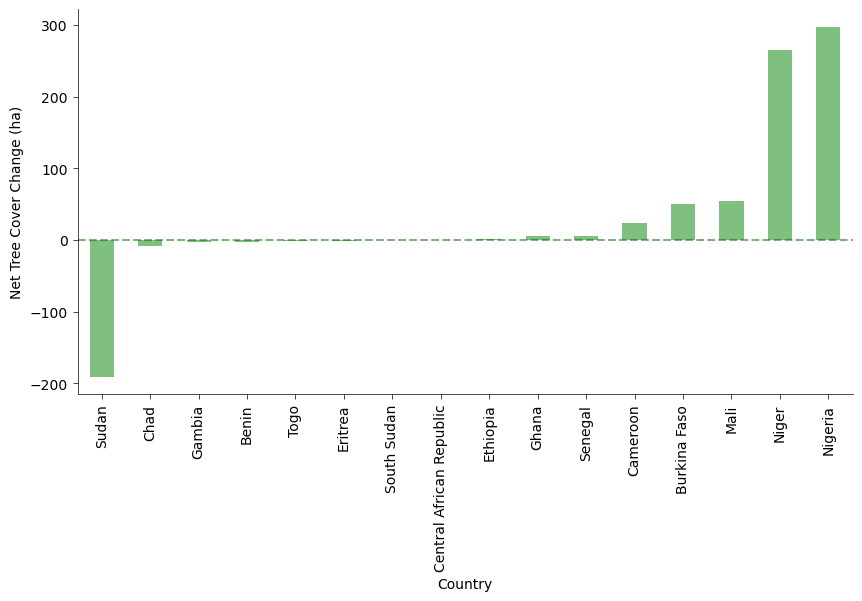

In [7]:
# group df by region but retain the country
df_region_sum = df.groupby(['region', 'country']).sum()
df_region_count = df.groupby(['region', 'country']).count()

df_country_sum = df.groupby(['country']).sum()
df_country_count = df.groupby(['country']).count()

# remove rows where country == mrt
df_country_sum = df_country_sum[df_country_sum.index != 'MRT']
df_country_sum = df_country_sum[df_country_sum.index != 'DJI']
df_country_sum = df_country_sum[df_country_sum.index != 'SSD']
df_country_sum = df_country_sum[df_country_sum.index != 'CAF']

df_region = df_region_sum #.div(total_area)
df_country = df_country_sum #.div(total_area)

df_region.sort_values(by="country", ascending=False, inplace=True)
#df_region.reset_index(inplace=True)
df_region["country"] = df_region.index.get_level_values(1)
df_region["region"] = df_region.index.get_level_values(0)
#df_region.reset_index(inplace=True)
df_region.set_index('region', inplace=True)

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
df_country.sort_values(by='net_diff_hct', ascending=True, inplace=True)
df_country.plot(kind='bar', y='net_diff_hct', ax=ax, alpha=0.5, color=['green'], legend=False)
# remove borders
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)

#set font ot arial

# 0 line
plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)

plt.ylabel('Net Tree Cover Change (ha)')
plt.xlabel('Country')
#plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_ls789_net_hct_ps.png', dpi=1000, bbox_inches='tight')
plt.show()

In [24]:
ps_df_country = ps_df.groupby(['country']).sum()
ag_2000_df_country = ag_2000_df.groupby(['country']).sum()
ag_2020_df_country = ag_2020_df.groupby(['country']).sum()

pos_diff_ha_ps = ps_df_country['pos_diff_hct']/1000
neg_diff_ha_ps = ps_df_country['neg_diff_hct']/1000

pos_diff_ha_ag_2000 = ag_2000_df_country['pos_diff_hct']/1000
neg_diff_ha_ag_2000 = ag_2000_df_country['neg_diff_hct']/1000

pos_diff_ha_ag_2020 = ag_2020_df_country['pos_diff_hct']/1000
neg_diff_ha_ag_2020 = ag_2020_df_country['neg_diff_hct']/1000
/1000
df = pd.concat([pos_diff_ha_ps, neg_diff_ha_ps, 
                    pos_diff_ha_ag_2000, neg_diff_ha_ag_2000, 
                    pos_diff_ha_ag_2020, neg_diff_ha_ag_2020], 
                   axis=1)

df.columns = ['pos_diff_ha_ps', 'neg_diff_ha_ps',
                    'pos_diff_ha_ag_2000', 'neg_diff_ha_ag_2000',
                    'pos_diff_ha_ag_2020', 'neg_diff_ha_ag_2020']

print(df)


                          pos_diff_ha_ps  neg_diff_ha_ps  pos_diff_ha_ag_2000  \
country                                                                         
Benin                           6.669222        1.411609            11.304271   
Burkina Faso                   58.440820        6.985829           107.239685   
Cameroon                       16.508955        1.532643            35.178873   
Central African Republic        0.276982        0.043250             0.604720   
Chad                           12.202653        2.205293            25.943356   
Eritrea                         2.095197        0.537869             5.008468   
Ethiopia                        8.185136        1.714402            18.549644   
Gambia                          0.235253        0.092415             0.491535   
Ghana                           5.131711        0.956825            10.970274   
MRT                             0.011438        0.002550             0.011350   
Mali                        

/tmp/ipykernel_219399/4277447573.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ps_df_country = ps_df.groupby(['country']).sum()
/tmp/ipykernel_219399/4277447573.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ag_2000_df_country = ag_2000_df.groupby(['country']).sum()
/tmp/ipykernel_219399/4277447573.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ag_2020_df_country = ag_2020_df.groupby(['country']).sum()


In [18]:
df_country_sum = df
# remove rows where country == mrt
df_country_sum = df_country_sum[df_country_sum.index != 'MRT']
df_country_sum = df_country_sum[df_country_sum.index != 'DJI']
df_country_sum = df_country_sum[df_country_sum.index != 'South Sudan']
df_country_sum = df_country_sum[df_country_sum.index != 'Central African Republic']
df_country_sum = df_country_sum[df_country_sum.index != 'Gambia']
df_country_sum = df_country_sum[df_country_sum.index != 'Togo']

df_country = df_country_sum
df_country_grouped = df_country.groupby(['country']).sum()
print(df_country_grouped["pos_area_ha"])
print(df_country_grouped["neg_area_ha"])
print(df_country_grouped['pos_diff_m2'])
print(df_country_grouped['neg_diff_m2'])


country
Benin                        54221.000500
Burkina Faso                616528.818500
Cameroon                    170871.701500
Central African Republic      2323.956500
Chad                        136112.673000
Eritrea                      29769.588000
Ethiopia                    111236.549500
Gambia                        2775.757500
Ghana                        58797.533500
MRT                             60.974000
Mali                        808994.776000
Niger                      2683584.570500
Nigeria                    3547158.881000
Senegal                     414567.278500
South Sudan                     33.776500
Sudan                       581343.660000
Togo                          6194.709000
Name: pos_area_ha, dtype: float64
country
Benin                        95278.970000
Burkina Faso                472067.287000
Cameroon                     78616.534500
Central African Republic      1156.807500
Chad                        340125.872000
Eritrea                   

/tmp/ipykernel_172327/3328473509.py:11: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_country_grouped = df_country.groupby(['country']).sum()


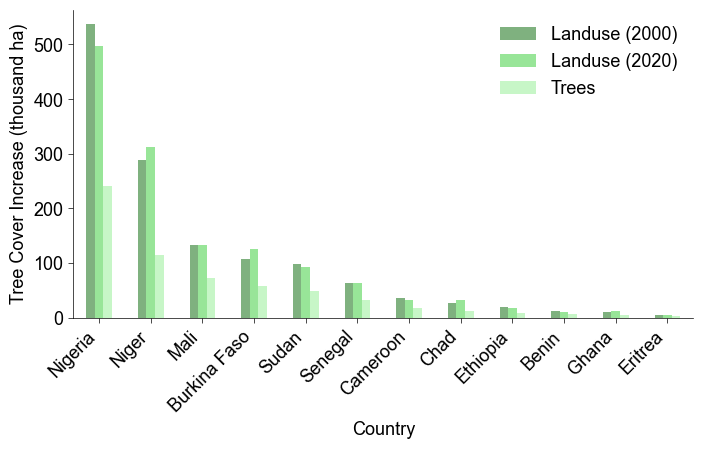

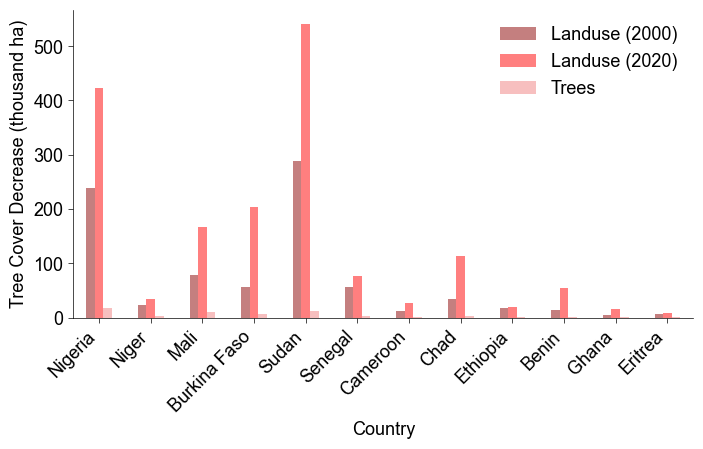

In [52]:
df_country_sum = df
# remove rows where country == mrt
df_country_sum = df_country_sum[df_country_sum.index != 'MRT']
df_country_sum = df_country_sum[df_country_sum.index != 'DJI']
df_country_sum = df_country_sum[df_country_sum.index != 'South Sudan']
df_country_sum = df_country_sum[df_country_sum.index != 'Central African Republic']
df_country_sum = df_country_sum[df_country_sum.index != 'Gambia']
df_country_sum = df_country_sum[df_country_sum.index != 'Togo']

df_country = df_country_sum


# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(8, 4))
# rank bar in order of largest
df_country.sort_values(by='pos_diff_ha_ag_2000', ascending=False, inplace=True)
df_country.plot(kind='bar', y=['pos_diff_ha_ag_2000', 'pos_diff_ha_ag_2020', 'pos_diff_ha_ps'], 
                ax=ax, alpha=0.5, color=['darkgreen', 'limegreen', 'lightgreen'], legend=False)
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

# 0 line
plt.legend(['Landuse (2000)', 'Landuse (2020)', 'Trees'], fontsize=13, frameon=False)
#plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)
#set font ot arial
#set font ot arial
plt.rcParams['font.family'] = 'Arial'

plt.ylabel('Tree Cover Increase (thousand ha)', fontsize=13)
plt.xlabel('Country', fontsize=13)

plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_increase_landuse.png', dpi=1000, bbox_inches='tight')

# save figures as vector graphics
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_increase_landuse.svg', bbox_inches='tight')

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(8, 4))
# rank bar in order of largest
df_country.sort_values(by='pos_diff_ha_ag_2000', ascending=False, inplace=True)
df_country.plot(kind='bar', y=['neg_diff_ha_ag_2000', 'neg_diff_ha_ag_2020', 'neg_diff_ha_ps'], 
                ax=ax, alpha=0.5, color=['darkred', 'red', 'lightcoral'], legend=False)
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

#set font ot arial
plt.rcParams['font.family'] = 'Arial'

# 0 line
plt.legend(['Landuse (2000)', 'Landuse (2020)', 'Trees'], fontsize=13, frameon=False)
#plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)

plt.ylabel('Tree Cover Decrease (thousand ha)', fontsize=13)
plt.xlabel('Country', fontsize=13)

plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_decrease_landuse.png', dpi=1000, bbox_inches='tight')


# save figures as vector graphics
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_decrease_landuse.svg', bbox_inches='tight')

In [ ]:


# group df by region but retain the country
df_region_sum = df.groupby(['region', 'country']).sum()
df_region_count = df.groupby(['region', 'country']).count()

df_country_sum = df.groupby(['country']).sum()
df_country_count = df.groupby(['country']).count()

# remove rows where country == mrt
df_country_sum = df_country_sum[df_country_sum.index != 'MRT']
df_country_sum = df_country_sum[df_country_sum.index != 'DJI']
df_country_sum = df_country_sum[df_country_sum.index != 'SSD']
df_country_sum = df_country_sum[df_country_sum.index != 'CAF']

df_region = df_region_sum #.div(total_area)
df_country = df_country_sum #.div(total_area)

df_region.sort_values(by="country", ascending=False, inplace=True)
#df_region.reset_index(inplace=True)
df_region["country"] = df_region.index.get_level_values(1)
df_region["region"] = df_region.index.get_level_values(0)
#df_region.reset_index(inplace=True)
df_region.set_index('region', inplace=True)

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
df_country.sort_values(by='pos_diff_hct', ascending=False, inplace=True)
df_country.plot(kind='bar', y=['pos_diff_hct', 'neg_diff_hct'], ax=ax, alpha=0.5, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
# 0 line
plt.legend(['Positive Change', 'Negative Change'])
#plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)

plt.ylabel('Tree Cover Change (ha)')
plt.xlabel('Country')

plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_ls789_new_percent_ps.png', dpi=1000, bbox_inches='tight')
plt.show()

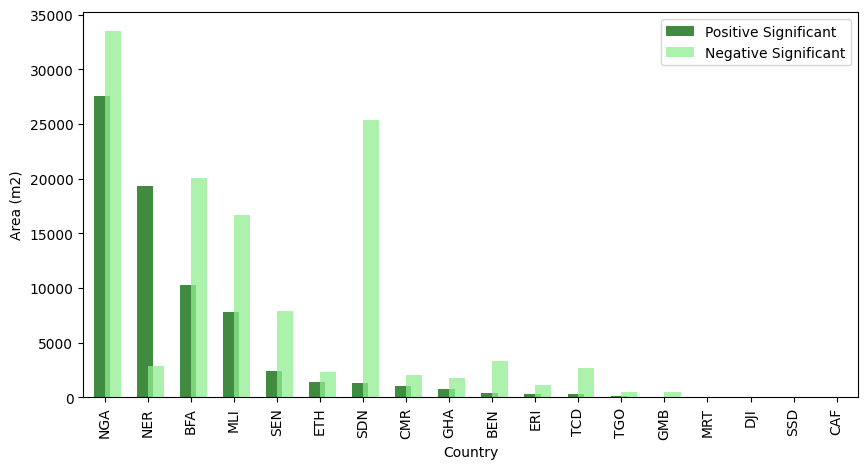

In [58]:
# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
df_country.sort_values(by='pos_area', ascending=False, inplace=True)
df_country.plot(kind='bar', y=['pos_area', 'neg_area'], ax=ax, alpha=0.75, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1.5)

plt.ylabel('Area (m2)')
plt.xlabel('Country')
plt.legend(['Positive Significant', 'Negative Significant'])
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_ls789_new.png', dpi=1000, bbox_inches='tight')
plt.show()

           pos_sig_diff  neg_sig_diff  pos_trend  neg_trend   pos_diff_m2  \
region                                                                      
Maradi         0.029256      0.001104   0.001561   0.000053 144607.827118   
Tahoua         0.002192      0.000096   0.000129   0.000004  10833.289061   
Tillabéri      0.000699      0.000151   0.000041   0.000007   3455.736871   
Zinder         0.019738      0.001129   0.001027   0.000061  97563.990715   
Dosso          0.005512      0.001421   0.000284   0.000071  27240.548733   

           neg_diff_m2  pos_pixels  neg_pixels  total_pixels  neg_area  ...  \
region                                                                  ...   
Maradi     5455.316645    67292952     3672300     202657575  0.078954  ...   
Tahoua      474.273563     4959224      332936      93910636  0.007158  ...   
Tillabéri   748.419818     1255885      404023     172984969  0.008686  ...   
Zinder     5581.279769    40434709     3935524     360821803  0.0

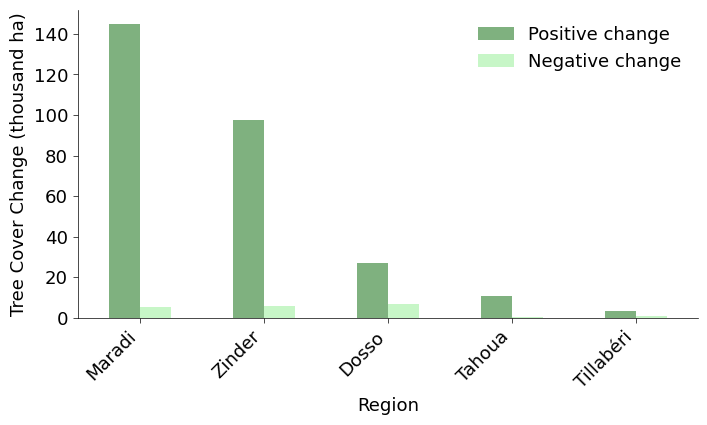

In [9]:

# group to Niger 
df_niger = df_region[df_region['country'] == 'Niger']

# remove rows where country == mrt
df_niger = df_niger[df_niger.index != 'Diffa']
df_niger = df_niger[df_niger.index != 'Agadez']

print(df_niger)

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(8, 4))
df_niger.sort_values(by='pos_diff_hct', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_diff_hct', 'neg_diff_hct'], ax=ax, alpha=0.5, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)    

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

plt.ylabel('Tree Cover Change (thousand ha)', fontsize=13)
plt.xlabel('Region', fontsize=13)
plt.legend(['Positive change', 'Negative change'], frameon=False, fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/niger_bars_ls789_.png', dpi=1000, bbox_inches='tight')
# save figures as vector graphics
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/niger_bars_ls789.svg', bbox_inches='tight')
plt.show()

In [74]:
df_niger.head()

,pos_sig_diff,neg_sig_diff,pos_trend,neg_trend,pos_diff_m2,neg_diff_m2,pos_pixels,neg_pixels,total_pixels,neg_area,pos_area,total_area,pos_diff_km2,neg_diff_km2,pos_diff_hct,neg_diff_hct,net_diff_hct,percent_positive,percent_negative,country
region,,,,,,,,,,,,,,,,,,,,
Maradi,0.029256,0.001104,0.001561,0.000053,144607.827118,5455.316645,67292952,3672300,202657575,0.078954,1.446798,9.576664e+07,1446.078271,54.553166,144.607827,5.455317,139.152510,0.000062,3.380230e-06,Niger
Zinder,0.019738,0.001129,0.001027,0.000061,97563.990715,5581.279769,40434709,3935524,360821803,0.084614,0.869346,1.705113e+08,975.639907,55.812798,97.563991,5.581280,91.982711,0.000037,3.622519e-06,Niger
Dosso,0.005512,0.001421,0.000284,0.000071,27240.548733,7025.170550,8981942,2523784,158162005,0.054261,0.193112,7.474470e+07,272.405487,70.251705,27.240549,7.025171,20.215378,0.000008,2.323059e-06,Niger
Tahoua,0.002192,0.000096,0.000129,0.000004,10833.289061,474.273563,4959224,332936,93910636,0.007158,0.106623,4.437966e+07,108.332891,4.742736,10.833289,0.474274,10.359015,0.000005,3.064565e-07,Niger
Tillabéri,0.000699,0.000151,0.000041,0.000007,3455.736871,748.419818,1255885,404023,172984969,0.008686,0.027002,8.175201e+07,34.557369,7.484198,3.455737,0.748420,2.707317,0.000001,3.718897e-07,Niger


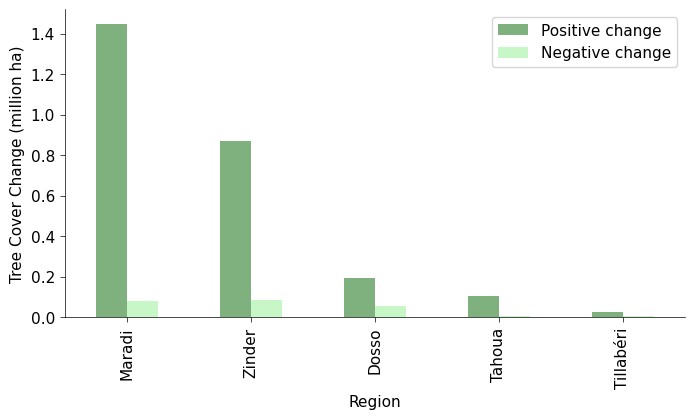

In [52]:
# group to Niger 
df_niger = df_region[df_region['country'] == 'NER']

# remove rows where country == mrt
df_niger = df_niger[df_niger.index != 'Diffa']
df_niger = df_niger[df_niger.index != 'Agadez']

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(8, 4))
df_niger.sort_values(by='pos_area', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_area', 'neg_area'], ax=ax, alpha=0.5, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)    

plt.ylabel('Tree Cover Change (million ha)', fontsize=11)
plt.xlabel('Region', fontsize=11)
plt.legend(['Positive change', 'Negative change'], fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
#plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/niger_bars_ls789_ps.png', dpi=1000, bbox_inches='tight')
plt.show()

pos_sig_diff        0.0
neg_sig_diff        0.0
pos_trend           0.0
neg_trend           0.0
pos_diff_m2         0.0
neg_diff_m2         0.0
pos_pixels          0.0
neg_pixels          0.0
total_pixels        0.0
neg_area            0.0
pos_area            0.0
total_area          0.0
pos_diff_km2        0.0
neg_diff_km2        0.0
pos_diff_hct        0.0
neg_diff_hct        0.0
net_diff_hct        0.0
percent_positive    0.0
percent_negative    0.0
country             0.0
dtype: float64


/tmp/ipykernel_435404/1727403415.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_niger.sort_values(by='pos_diff_hct', ascending=False, inplace=True)


IndexError: index 0 is out of bounds for axis 0 with size 0

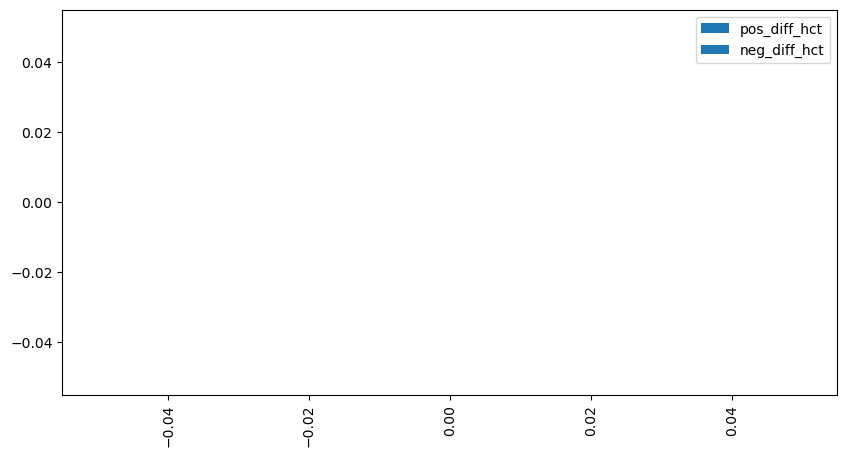

In [62]:
# group to Niger 
df_niger = df_region[df_region['country'] == 'NGA']

# remove rows where country == mrt
#df_niger = df_niger[df_niger.index != 'Diffa']
#df_niger = df_niger[df_niger.index != 'Agadez']

print(df_niger.sum())

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
df_niger.sort_values(by='pos_diff_hct', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_diff_hct', 'neg_diff_hct'], ax=ax, alpha=0.5, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
plt.title('Niger')
plt.ylabel('Tree Cover Change (thousand ha)')
plt.xlabel('Region')
plt.legend(['Positive Change', 'Negative Change'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/nigeria_bars_ls789_2000.pdf', dpi=1000, bbox_inches='tight')
plt.show()

In [39]:
# group df by region but retain the country
df_region_sum = df.groupby(['region', 'country']).sum().mul(100)
df_region_count = df.groupby(['region', 'country']).count()

df_country_sum = df.groupby(['country']).sum().mul(100)
df_country_count = df.groupby(['country']).count()

df_region = df_region_sum.div(len(df_country_sum.index))
df_country = df_country_sum.div(len(df_country_sum.index))

df_region.sort_values(by="country", ascending=False, inplace=True)
#df_region.reset_index(inplace=True)
df_region["country"] = df_region.index.get_level_values(1)
df_region["region"] = df_region.index.get_level_values(0)
#df_region.reset_index(inplace=True)
df_region.set_index('region', inplace=True)

/tmp/ipykernel_2182820/2623378522.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_region_sum = df.groupby(['region', 'country']).sum().mul(100)
/tmp/ipykernel_2182820/2623378522.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_country_sum = df.groupby(['country']).sum().mul(100)


In [36]:
print(df_country_count)
print(df_country)
print(df_region_count)
print(df_region)

         geometry  tile_id  region  pos_sig_diff  neg_sig_diff  pos_trend  \
country                                                                     
BEN            29       29      29            29            29         29   
BFA           214      214     214           214           214        214   
CAF            19       19      19            19            19         19   
CMR            46       46      46            46            46         46   
DJI             5        5       5             5             5          5   
ERI            25       25      25            25            25         25   
ETH           103      103     103           103           103        103   
GHA            31       31      31            31            31         31   
GMB             2        2       2             2             2          2   
MLI           281      281     281           281           281        281   
MRT            19       19      19            19            19         19   

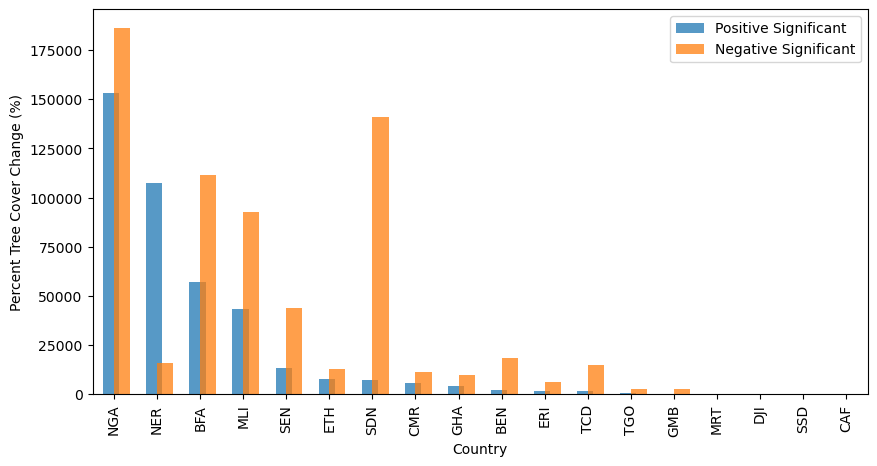

In [41]:
# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
df_country.sort_values(by='pos_sig_diff', ascending=False, inplace=True)
df_country.plot(kind='bar', y=['pos_sig_diff', 'neg_sig_diff'], ax=ax, alpha=0.75)
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1.5)

plt.ylabel('Percent Tree Cover Change (%)')
plt.xlabel('Country')
plt.legend(['Positive Significant', 'Negative Significant'])
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_ls789_new.png', dpi=1000, bbox_inches='tight')
plt.show()


In [55]:
canopy_change_sum = df_country.sum()
print(canopy_change_sum)

pos_sig_diff       1.102364
neg_sig_diff       2.188493
pos_nonsig_diff    0.057258
neg_nonsig_diff    0.114310
dtype: float64


pos_sig_diff                    0.227867
neg_sig_diff                    0.032847
pos_nonsig_diff                 0.018959
neg_nonsig_diff                 0.005381
country            NERNERNERNERNERNERNER
dtype: object


/tmp/ipykernel_3655805/3660414003.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_niger.sort_values(by='pos_sig_diff', ascending=False, inplace=True)


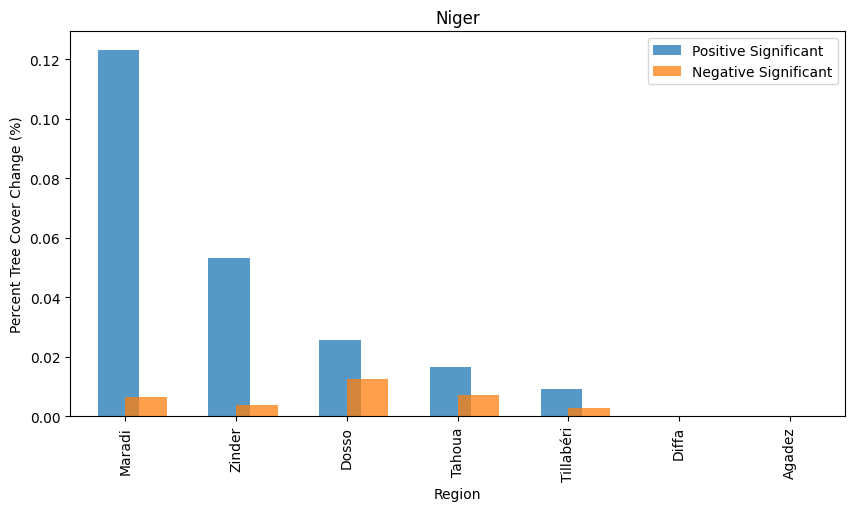

In [7]:
# group to Niger 
df_niger = df_region[df_region['country'] == 'NER']
print(df_niger.sum())

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
df_niger.sort_values(by='pos_diff_m2', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_diff_m2', 'neg_diff_m2'], ax=ax, alpha=0.75)
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1.5)
plt.title('Niger')
plt.ylabel('Percent Tree Cover Change (%)')
plt.xlabel('Region')
plt.legend(['Positive Significant', 'Negative Significant'])
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/niger_bars_ls789_new.png', dpi=1000, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3655805/375406081.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_niger.sort_values(by='pos_sig_diff', ascending=False, inplace=True)


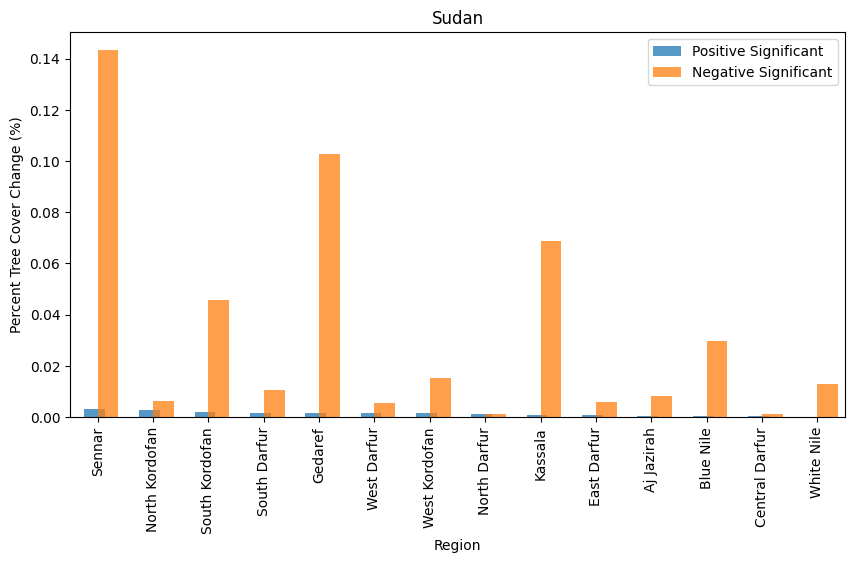

In [10]:
# group to Senegal 
df_niger = df_region[df_region['country'] == 'SDN']

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
df_niger.sort_values(by='pos_sig_diff', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_sig_diff', 'neg_sig_diff'], ax=ax, alpha=0.75)
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1.5)
    
plt.title('Sudan')
plt.ylabel('Percent Tree Cover Change (%)')
plt.legend(['Positive Significant', 'Negative Significant'])
plt.xlabel('Region')
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sudan_bars_ls789_new.png', dpi=1000, bbox_inches='tight')
plt.show()

In [31]:
import geopandas as gpd
buffered = gpd.read_file("/mnt/sdc/tree_density_and_coverage/shapefiles/sahel_downloader/urban_buffer_zones_country_area_mean_diff_v7.gpkg")

In [32]:
# remove overlapping geometries
buffered_valid = buffered[buffered["_mean"].isna() == False]
buffered_valid.sort_values(by="_mean", ascending=False, inplace=True)
#buffered_valid.head(20)


/tmp/ipykernel_219399/1531941329.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  buffered_valid.sort_values(by="_mean", ascending=False, inplace=True)


In [33]:
buffered_filtered = buffered[~buffered['_mean'].isnull()]

# group by ring id and sum the mean tree cover
buffered_filtered["_mean"] = buffered_filtered["_mean"].mul(100)
buffered_filtered["area_ha"] = buffered_filtered["area"]/10000
buffered_filtered["distance_km"] = buffered_filtered["distance"]/1000
buffered_filtered['area_category'] = pd.cut(buffered_filtered['area_ha'], bins=[0, 20, 50, 100, 10000], labels=['0-20ha', '20-50ha', '50-100ha', '>100ha'])
#buffered_filtered.hist(column='area_ha', bins=100, log=True)
buffered_filtered_sum = buffered_filtered.groupby('ringId').mean()


buffered_filtered_1 = buffered_filtered[buffered_filtered['ringId'] == 1].groupby('area_category').mean()
buffered_filtered_2 = buffered_filtered[buffered_filtered['ringId'] == 2].groupby('area_category').mean()
buffered_filtered_3 = buffered_filtered[buffered_filtered['ringId'] == 3].groupby('area_category').mean()
buffered_filtered_4 = buffered_filtered[buffered_filtered['ringId'] == 4].groupby('area_category').mean()
buffered_filtered_4.head()

/home/rene1337/miniconda3/envs/gdal/lib/python3.10/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/rene1337/miniconda3/envs/gdal/lib/python3.10/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/rene1337/miniconda3/envs/gdal/lib/python3.10/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of

,fid,DN,area,perimeter,ringId,distance,_mean,area_ha,distance_km
area_category,,,,,,,,,
0-20ha,364995.377438,1.000000,103504.295292,1963.476000,4.000000,2000.000000,0.060412,10.350430,2.000000
20-50ha,355643.536973,1.000000,302961.803381,4248.818808,4.000000,2000.000000,0.053548,30.296180,2.000000
50-100ha,367896.862457,1.000000,683964.757709,7896.328928,4.000000,2000.000000,0.026125,68.396476,2.000000
>100ha,380077.362651,1.000000,3138920.383493,22691.037932,4.000000,2000.000000,0.029922,313.892038,2.000000


In [51]:
buffered_filtered_1.head()

,fid,DN,area,perimeter,ringId,distance,_mean,area_ha,distance_km
area_category,,,,,,,,,
0-20ha,364547.747950,1.0,1.034980e+05,1963.521819,1.0,500.0,0.089184,10.349795,0.5
20-50ha,355191.584384,1.0,3.030028e+05,4250.596194,1.0,500.0,0.112005,30.300275,0.5
50-100ha,367167.520643,1.0,6.838195e+05,7900.667491,1.0,500.0,0.125748,68.381953,0.5
>100ha,380225.732661,1.0,3.117306e+06,22682.555696,1.0,500.0,0.108613,311.730559,0.5


In [19]:
buffered_filtered_sum["distance_km"] = buffered_filtered_sum['distance'] / 1000
buffered_filtered_sum

,fid,DN,area,perimeter,distance,_mean,area_ha,distance_km
ringId,,,,,,,,
1,363413.441324,1.000000,251445.282574,3145.899385,500.000000,0.094992,25.144528,0.500000
2,363563.813467,1.000000,251377.387521,3145.372938,1000.000000,0.067819,25.137739,1.000000
3,363684.723693,1.000000,252014.444738,3146.847666,1500.000000,0.059755,25.201444,1.500000
4,363859.734839,1.000000,251996.703050,3146.614774,2000.000000,0.057154,25.199670,2.000000


In [34]:
buffered_filtered["distance_km"] = buffered_filtered['distance'] / 1000
buffered_filtered_1 = buffered_filtered[buffered_filtered['area_category'] == '0-20ha'].groupby('ringId').mean()
buffered_filtered_2 = buffered_filtered[buffered_filtered['area_category'] == '20-50ha'].groupby('ringId').mean()
buffered_filtered_3 = buffered_filtered[buffered_filtered['area_category'] == '50-100ha'].groupby('ringId').mean()
buffered_filtered_4 = buffered_filtered[buffered_filtered['area_category'] == '>100ha'].groupby('ringId').mean()



/home/rene1337/miniconda3/envs/gdal/lib/python3.10/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_219399/4012430840.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  buffered_filtered_1 = buffered_filtered[buffered_filtered['area_category'] == '0-20ha'].groupby('ringId').mean()
/tmp/ipykernel_219399/4012430840.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Eithe

In [54]:
buffered_filtered_4.head()

,fid,DN,area,perimeter,distance,_mean,area_ha,distance_km
ringId,,,,,,,,
1,380225.732661,1.0,3.117306e+06,22682.555696,500.0,0.108613,311.730559,0.5
2,380348.701762,1.0,3.115973e+06,22665.100671,1000.0,0.092212,311.597315,1.0
3,380134.301421,1.0,3.141706e+06,22716.053512,1500.0,0.048399,314.170569,1.5
4,380077.362651,1.0,3.138920e+06,22691.037932,2000.0,0.029922,313.892038,2.0


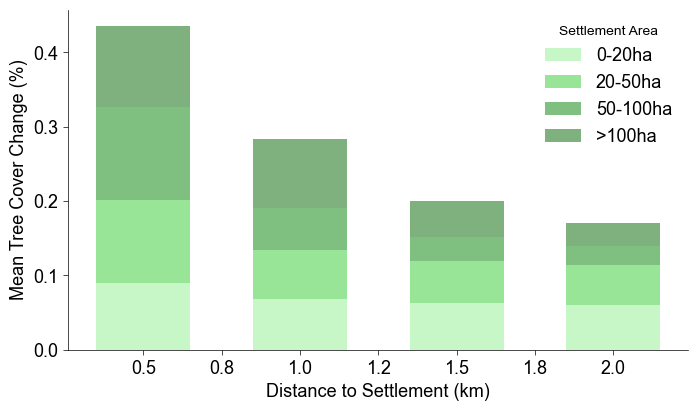

In [45]:
#plot all on same stacked bar chart
from tkinter import font
import matplotlib.pyplot as plt
import numpy as np

X_axis = [0.5, 1, 1.5, 2]

# Convert the data to lists
data_1 = buffered_filtered_1['_mean'].tolist()
data_2 = buffered_filtered_2['_mean'].tolist()
data_3 = buffered_filtered_3['_mean'].tolist()
data_4 = buffered_filtered_4['_mean'].tolist()

fix, ax = plt.subplots(figsize=(8, 5))

# set x and y ticks to 1 decimal place
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))

# Plot the stacked bar
plt.bar(X_axis, data_1, 0.3, label='0-20ha', color="lightgreen", alpha=0.5)
plt.bar(X_axis, data_2, 0.3, bottom=data_1, label='20-50ha', color="limegreen", alpha=0.5)
plt.bar(X_axis, data_3, 0.3, bottom=np.array(data_1) + np.array(data_2), label='50-100ha', color="green", alpha=0.5)
plt.bar(X_axis, data_4, 0.3, bottom=np.array(data_1) + np.array(data_2) + np.array(data_3), label='>100ha', color="darkgreen", alpha=0.5)

#plt.xticks(X_axis, X, rotation=45, ha='right')
plt.subplots_adjust(bottom=0.2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5, labelsize=13)
ax.tick_params(axis='y', colors='black', width = 0.5, labelsize=13)

# remove legend border
# increase size of legend title font

ax.legend(title= 'Settlement Area', frameon=False, fontsize=13)

plt.xlabel("Distance to Settlement (km)", fontsize=13)
plt.ylabel("Mean Tree Cover Change (%)", fontsize=13)

plt.savefig("/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_wide_buffer_total_new_v2.png", dpi=1000, bbox_inches='tight')
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_wide_buffer_total_new_v2.svg', bbox_inches='tight')
plt.show()